In [ ]:
import warnings, ccxt
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 4), "axes.grid": True, "grid.alpha": 0.3})
print("Imports OK")

Imports OK


### Load Daily Data (2023-2026 CSV)

In [ ]:
# load daily CSV
daily = pd.read_csv("bitcoin_2023-03-09_2026-03-08.csv", parse_dates=["Start"])
daily = daily.sort_values("Start").reset_index(drop=True)
daily = daily.rename(columns={"Start": "date", "Close": "close"})
daily = daily.set_index("date")[["close"]]
print(f"Daily shape: {daily.shape}  |  Range: {daily.index.min().date()} → {daily.index.max().date()}")
daily.head()

Daily shape: (1095, 1)  |  Range: 2023-03-09 → 2026-03-07


,close
date,
2023-03-09,20355.860400
2023-03-10,20133.739824
2023-03-11,20494.936800
2023-03-12,21952.797808
2023-03-13,24063.562447


### Load Minute Data

In [ ]:
# fetch minute-level BTC/USD from Kraken
EXCHANGE_NAME = "kraken"
exchange = getattr(ccxt, EXCHANGE_NAME)({"enableRateLimit": True})
exchange.load_markets()
print(f"Connected to {EXCHANGE_NAME}")

symbol, timeframe, limit = "BTC/USD", "1m", 300

ohlcv = exchange.fetch_ohlcv(symbol=symbol, timeframe=timeframe, limit=limit)
minute = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
minute["timestamp"] = pd.to_datetime(minute["timestamp"], unit="ms")
minute = minute.set_index("timestamp")[["close"]]

print(f"Minute shape: {minute.shape}  |  Range: {minute.index.min()} → {minute.index.max()}")
minute.tail()

Connected to kraken
Minute shape: (300, 1)  |  Range: 2026-03-11 15:31:00 → 2026-03-11 20:30:00


,close
timestamp,
2026-03-11 20:26:00,70445.1
2026-03-11 20:27:00,70422.4
2026-03-11 20:28:00,70453.1
2026-03-11 20:29:00,70459.8
2026-03-11 20:30:00,70463.7


### Summary Stats

In [7]:
for label, df in [("Daily", daily), ("Minute", minute)]:
    print(f"\n{'='*60}")
    print(f"  {label} Close — Summary Statistics")
    print(f"{'='*60}")
    print(df["close"].describe().to_string())
    print(f"\nMissing values : {df['close'].isna().sum()}")
    print(f"Duplicated idx : {df.index.duplicated().sum()}")


  Daily Close — Summary Statistics
count      1095.000000
mean      68976.241838
std       30041.557510
min       20133.739824
25%       40683.475000
50%       67440.040000
75%       95630.040000
max      124735.000000

Missing values : 0
Duplicated idx : 0

  Minute Close — Summary Statistics
count      300.000000
mean     70618.915333
std        250.079288
min      69850.200000
25%      70478.125000
50%      70641.050000
75%      70756.925000
max      71341.000000

Missing values : 0
Duplicated idx : 0


### Time-Series Line Plots

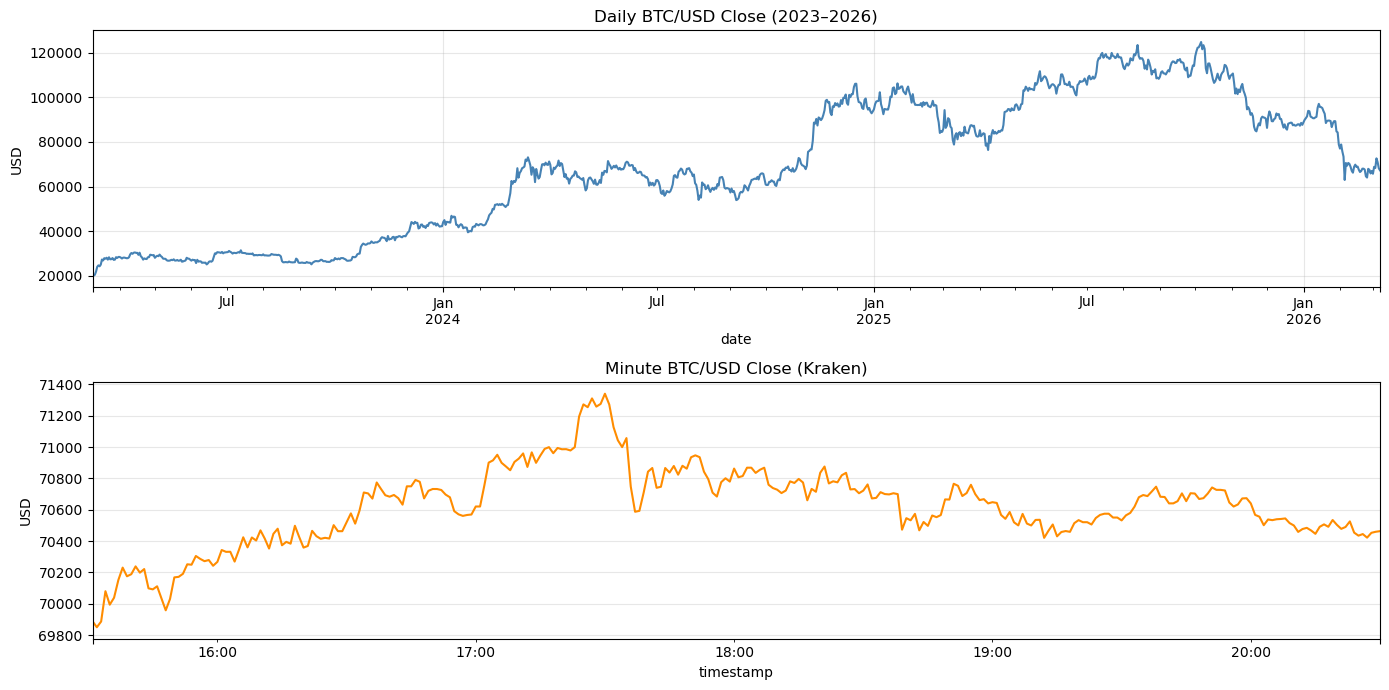

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
daily["close"].plot(ax=axes[0], title="Daily BTC/USD Close (2023–2026)", color="steelblue")
axes[0].set_ylabel("USD")
minute["close"].plot(ax=axes[1], title="Minute BTC/USD Close (Kraken)", color="darkorange")
axes[1].set_ylabel("USD")
plt.tight_layout()
plt.show()

### Distribution Analysis

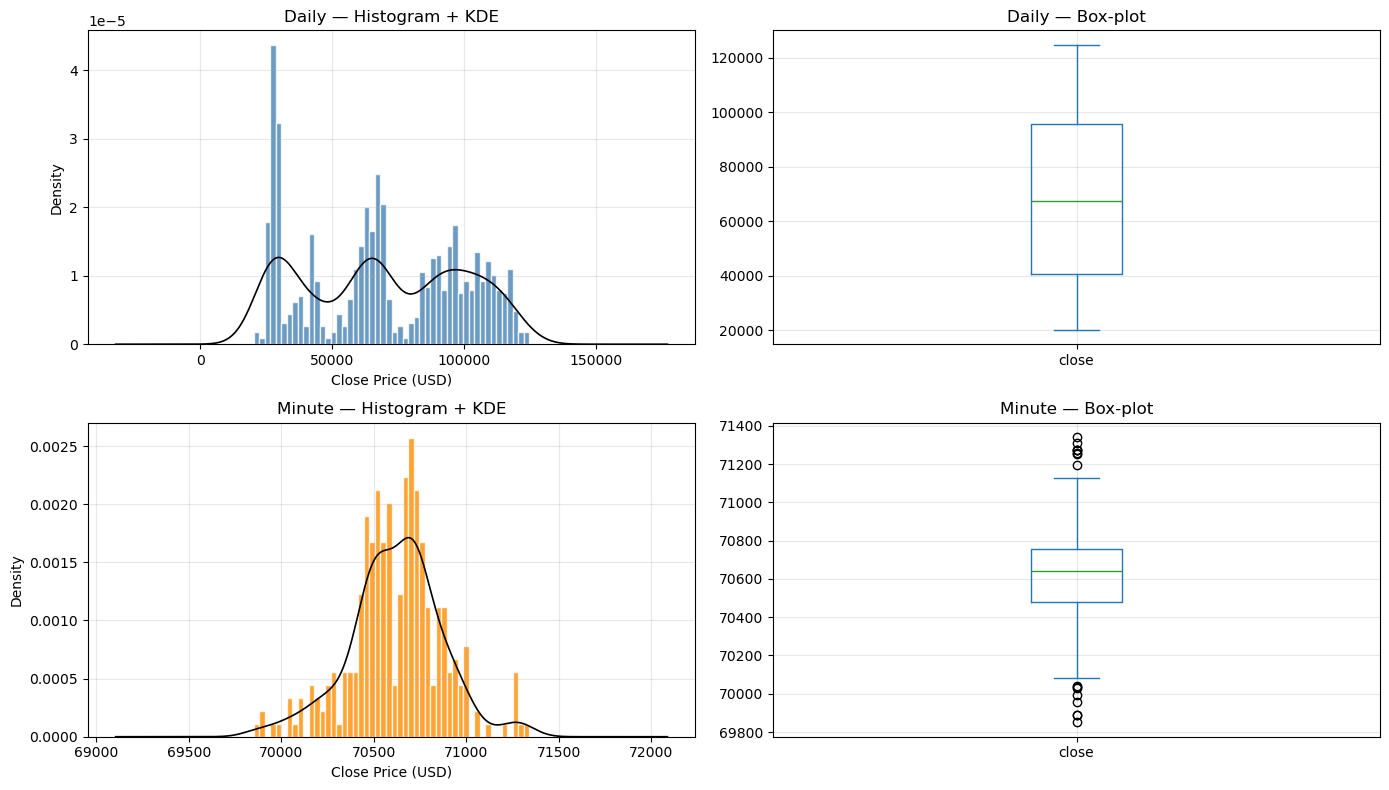

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (label, df, color) in enumerate([("Daily", daily, "steelblue"), ("Minute", minute, "darkorange")]):
    df["close"].plot.hist(bins=50, ax=axes[i, 0], color=color, edgecolor="white", alpha=0.8, density=True)
    df["close"].plot.kde(ax=axes[i, 0], color="black", linewidth=1.2)
    axes[i, 0].set_title(f"{label} — Histogram + KDE")
    axes[i, 0].set_xlabel("Close Price (USD)")

    df["close"].plot.box(ax=axes[i, 1], vert=True)
    axes[i, 1].set_title(f"{label} — Box-plot")
plt.tight_layout()
plt.show()

### Rolling Statistics (Visual Stationarity Check)

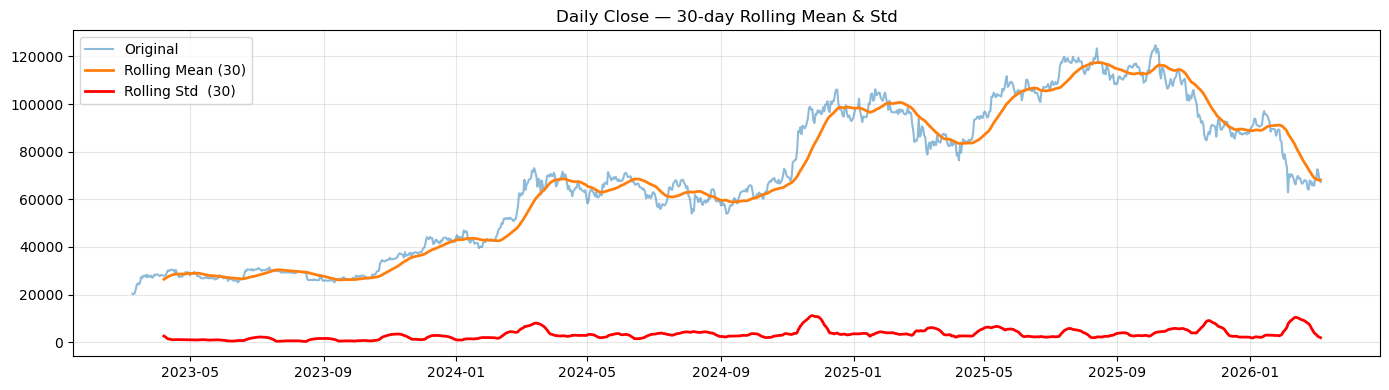

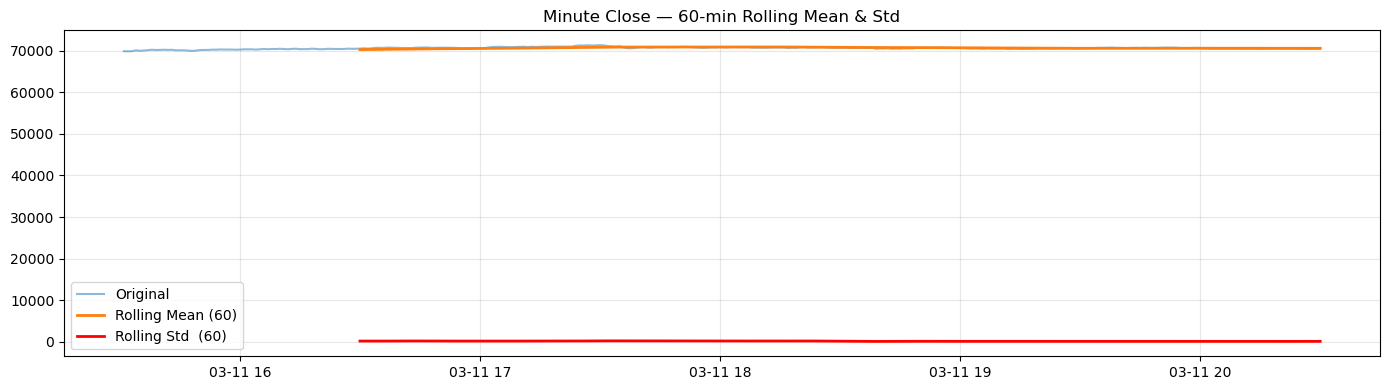

In [10]:
def plot_rolling(series, window, title):
    roll_mean = series.rolling(window).mean()
    roll_std  = series.rolling(window).std()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(series, label="Original", alpha=0.5)
    ax.plot(roll_mean, label=f"Rolling Mean ({window})", linewidth=2)
    ax.plot(roll_std,  label=f"Rolling Std  ({window})", linewidth=2, color="red")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout(); plt.show()

plot_rolling(daily["close"], window=30, title="Daily Close — 30-day Rolling Mean & Std")
plot_rolling(minute["close"], window=60, title="Minute Close — 60-min Rolling Mean & Std")

### Stationarity Tests (ADF & KPSS)

In [11]:
def stationarity_tests(series, name):
    print(f"\n{'='*60}")
    print(f"  Stationarity Tests — {name}")
    print(f"{'='*60}")

    # ADF
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(series.dropna(), autolag="AIC")
    print(f"\n  ADF Test:")
    print(f"    Statistic : {adf_stat:.4f}")
    print(f"    p-value   : {adf_p:.6f}")
    for k, v in adf_crit.items():
        print(f"    Crit {k:>3s}  : {v:.4f}")
    print(f"    → {'Stationary' if adf_p < 0.05 else 'Non-stationary'} at 5% level")

    # KPSS
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\n  KPSS Test:")
    print(f"    Statistic : {kpss_stat:.4f}")
    print(f"    p-value   : {kpss_p:.4f}")
    for k, v in kpss_crit.items():
        print(f"    Crit {k:>4s} : {v:.4f}")
    print(f"    → {'Non-stationary' if kpss_p < 0.05 else 'Stationary'} at 5% level")

stationarity_tests(daily["close"], "Daily Close")
stationarity_tests(minute["close"], "Minute Close")


  Stationarity Tests — Daily Close

  ADF Test:
    Statistic : -1.6408
    p-value   : 0.461830
    Crit  1%  : -3.4363
    Crit  5%  : -2.8642
    Crit 10%  : -2.5682
    → Non-stationary at 5% level

  KPSS Test:
    Statistic : 4.5208
    p-value   : 0.0100
    Crit  10% : 0.3470
    Crit   5% : 0.4630
    Crit 2.5% : 0.5740
    Crit   1% : 0.7390
    → Non-stationary at 5% level

  Stationarity Tests — Minute Close

  ADF Test:
    Statistic : -3.0918
    p-value   : 0.027167
    Crit  1%  : -3.4524
    Crit  5%  : -2.8713
    Crit 10%  : -2.5719
    → Stationary at 5% level

  KPSS Test:
    Statistic : 0.6134
    p-value   : 0.0214
    Crit  10% : 0.3470
    Crit   5% : 0.4630
    Crit 2.5% : 0.5740
    Crit   1% : 0.7390
    → Non-stationary at 5% level


### STL Decomposition

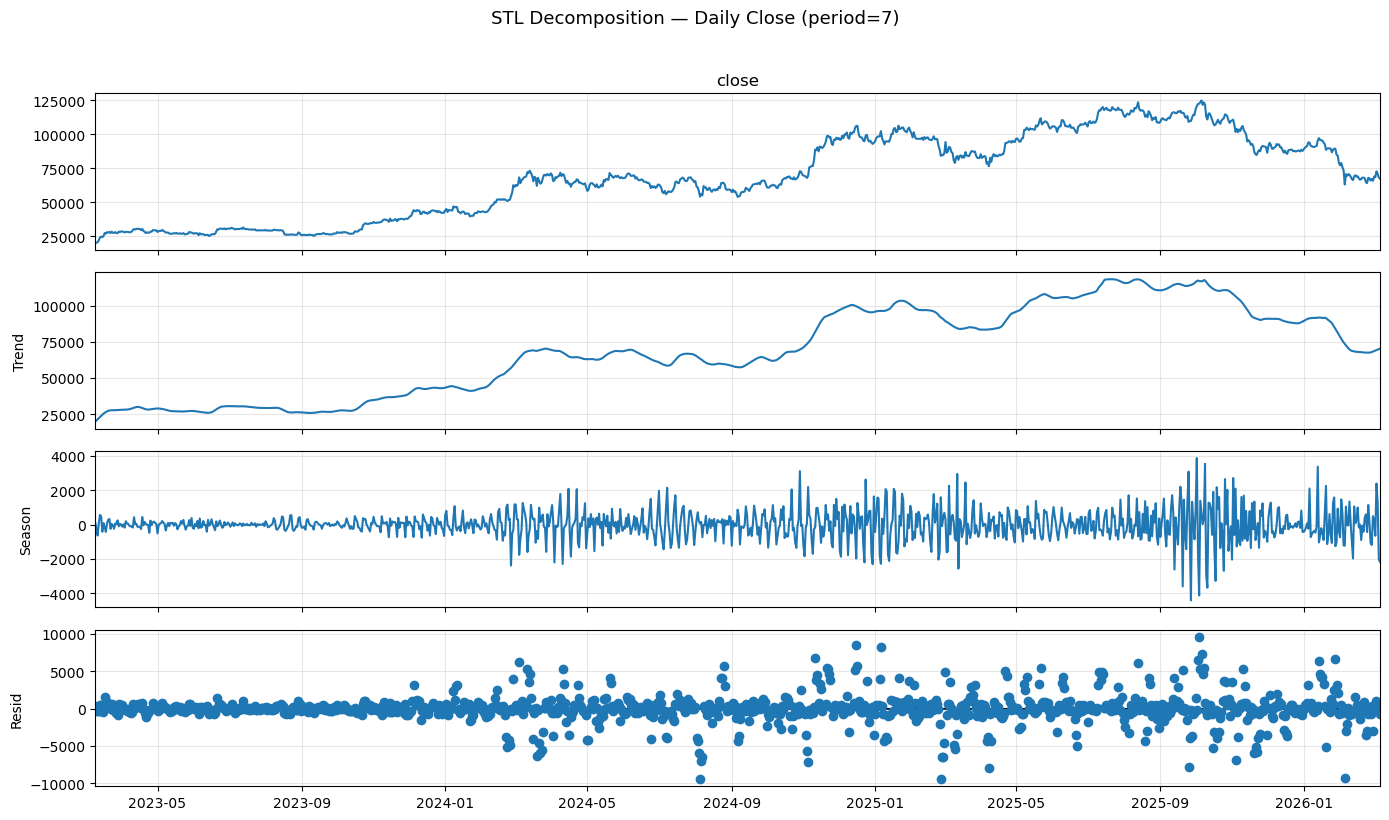

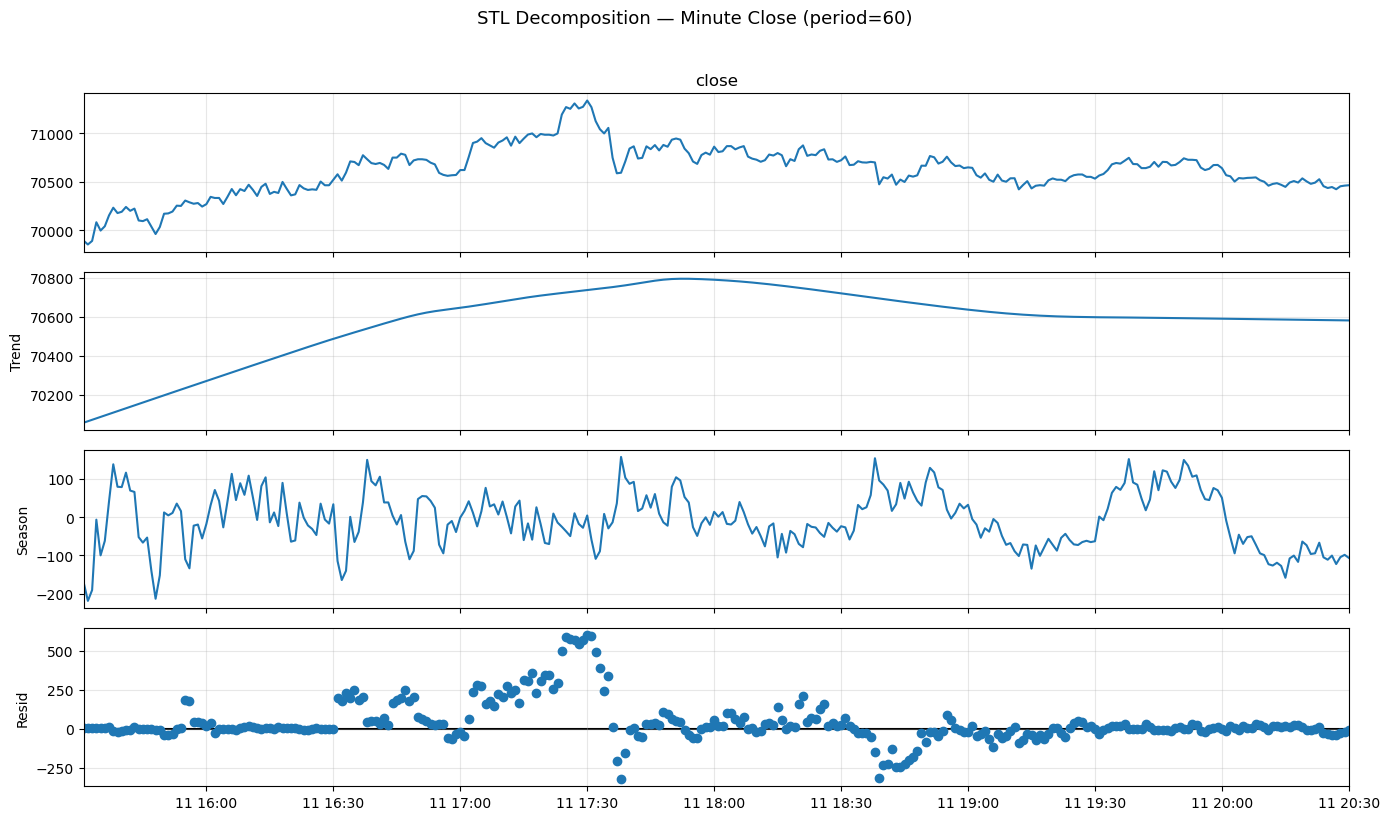

In [12]:
# STL on Daily (period=7 for weekly seasonality)
daily_freq = daily["close"].asfreq("D").ffill()
stl_daily = STL(daily_freq, period=7, robust=True).fit()
fig = stl_daily.plot()
fig.suptitle("STL Decomposition — Daily Close (period=7)", y=1.02, fontsize=13)
fig.set_size_inches(14, 8)
plt.tight_layout(); plt.show()

# STL on Minute (period=60 for hourly cycle)
minute_freq = minute["close"].asfreq("min").ffill()
stl_minute = STL(minute_freq, period=60, robust=True).fit()
fig = stl_minute.plot()
fig.suptitle("STL Decomposition — Minute Close (period=60)", y=1.02, fontsize=13)
fig.set_size_inches(14, 8)
plt.tight_layout(); plt.show()

### Classical Multiplicative Decomposition

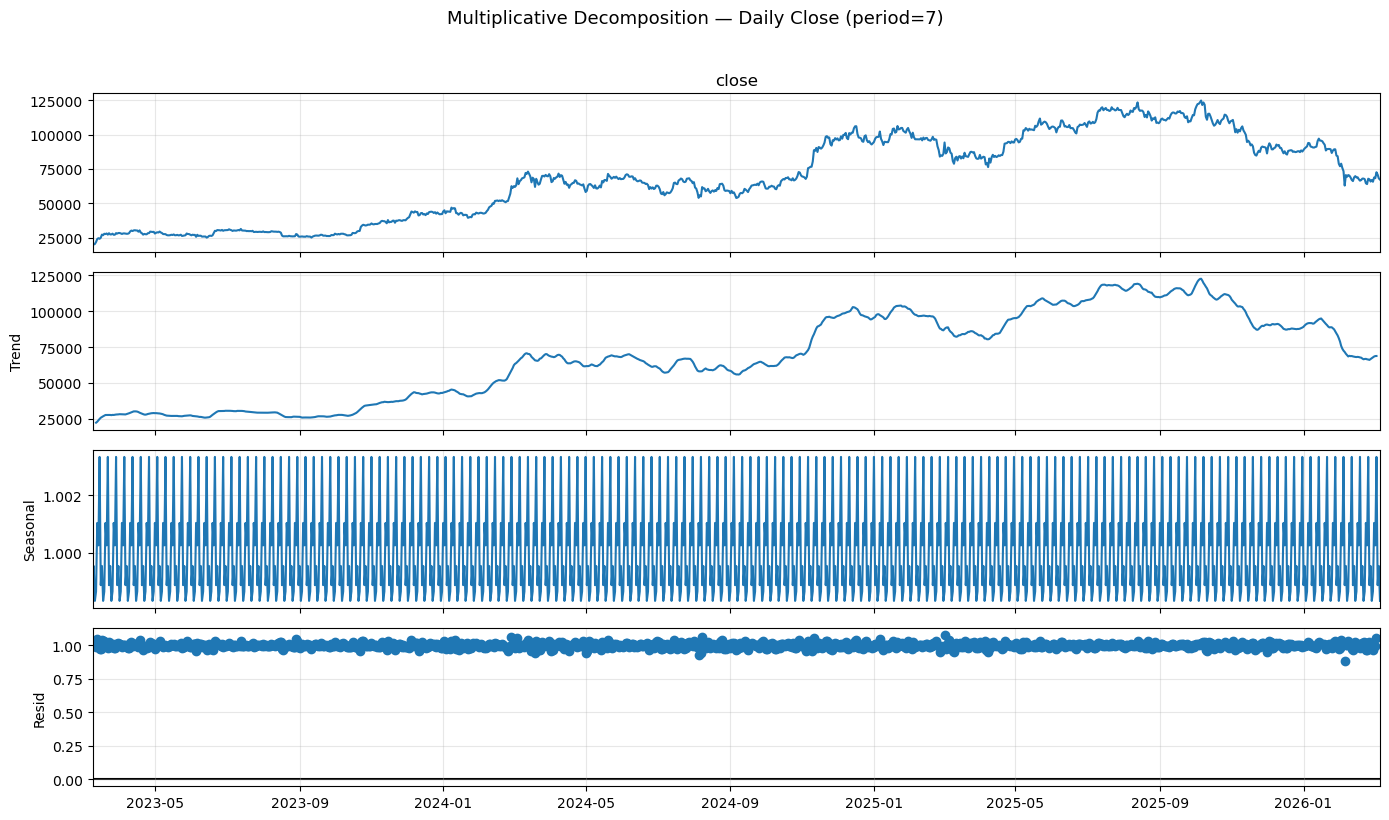

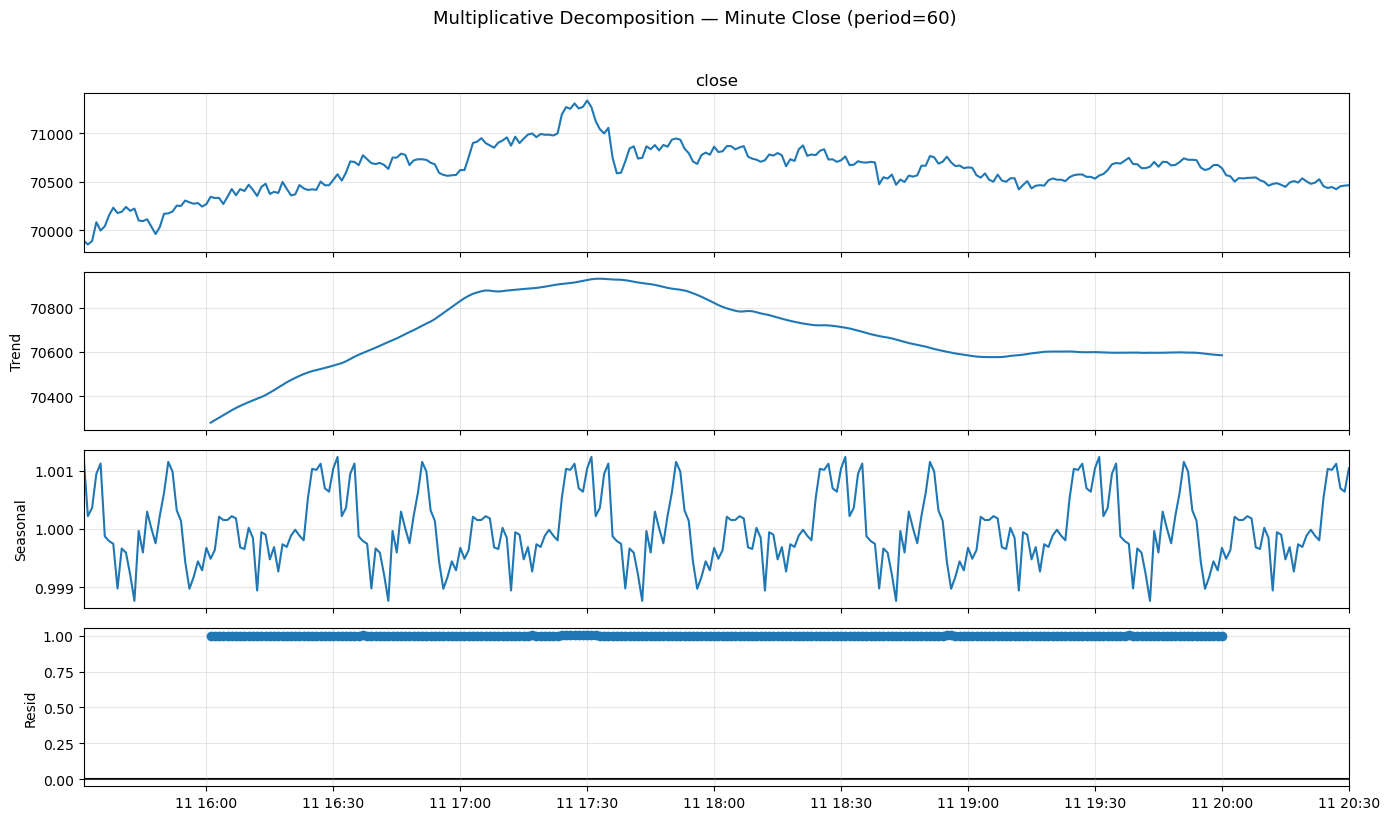

In [ ]:
# multiplicative decomposition Daily (period=7)
mult_daily = seasonal_decompose(daily_freq, model="multiplicative", period=7)
fig = mult_daily.plot()
fig.suptitle("Multiplicative Decomposition — Daily Close (period=7)", y=1.02, fontsize=13)
fig.set_size_inches(14, 8)
plt.tight_layout(); plt.show()

# multiplicative decomposition Minute (period=60)
mult_minute = seasonal_decompose(minute_freq, model="multiplicative", period=60)
fig = mult_minute.plot()
fig.suptitle("Multiplicative Decomposition — Minute Close (period=60)", y=1.02, fontsize=13)
fig.set_size_inches(14, 8)
plt.tight_layout(); plt.show()

### ACF & PACF Plots

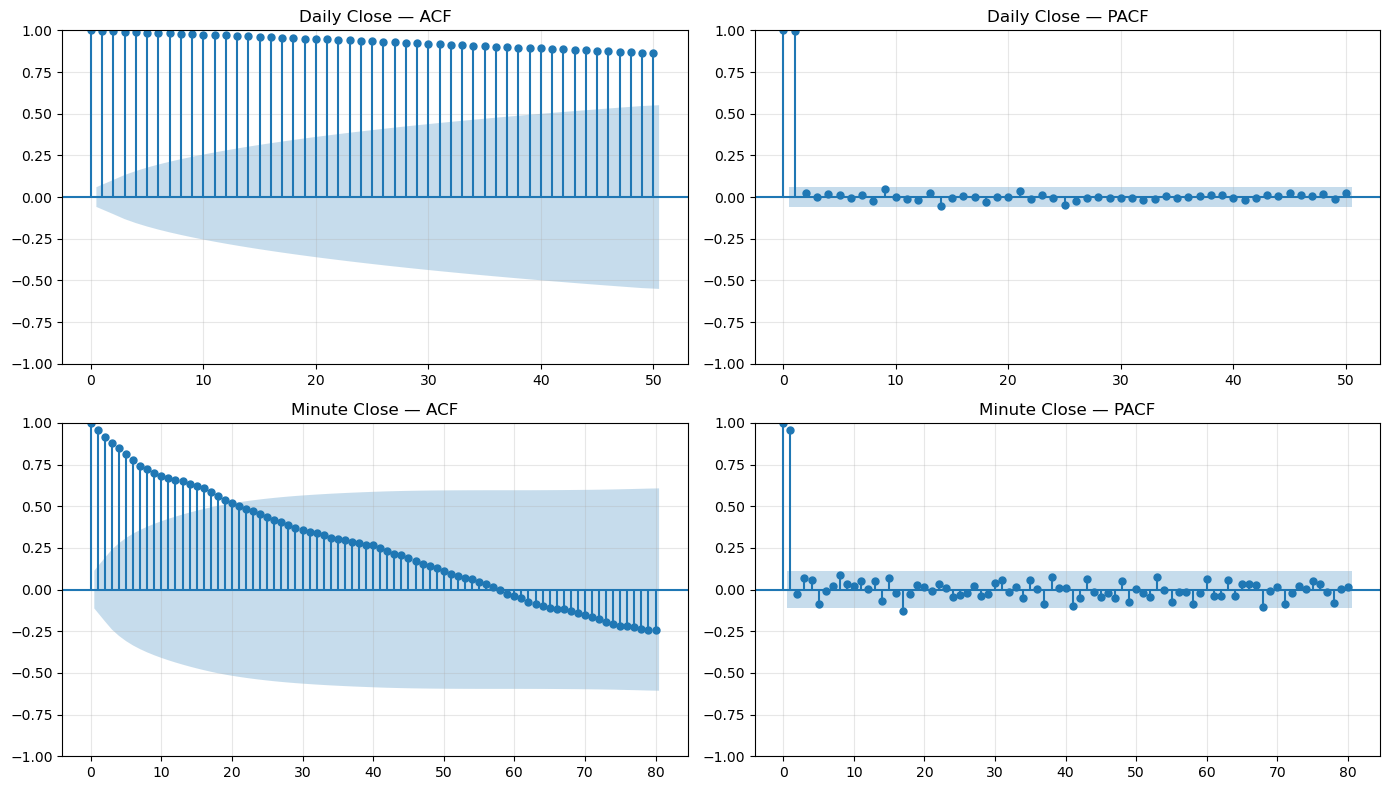

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(daily["close"].dropna(),  lags=50, ax=axes[0, 0], title="Daily Close — ACF")
plot_pacf(daily["close"].dropna(), lags=50, ax=axes[0, 1], title="Daily Close — PACF", method="ywm")

plot_acf(minute["close"].dropna(),  lags=80, ax=axes[1, 0], title="Minute Close — ACF")
plot_pacf(minute["close"].dropna(), lags=80, ax=axes[1, 1], title="Minute Close — PACF", method="ywm")

plt.tight_layout(); plt.show()

### ACF / PACF on First-Differenced Series
If the raw series is non-stationary, differencing helps reveal the underlying autocorrelation structure needed for ARIMA-type modelling.

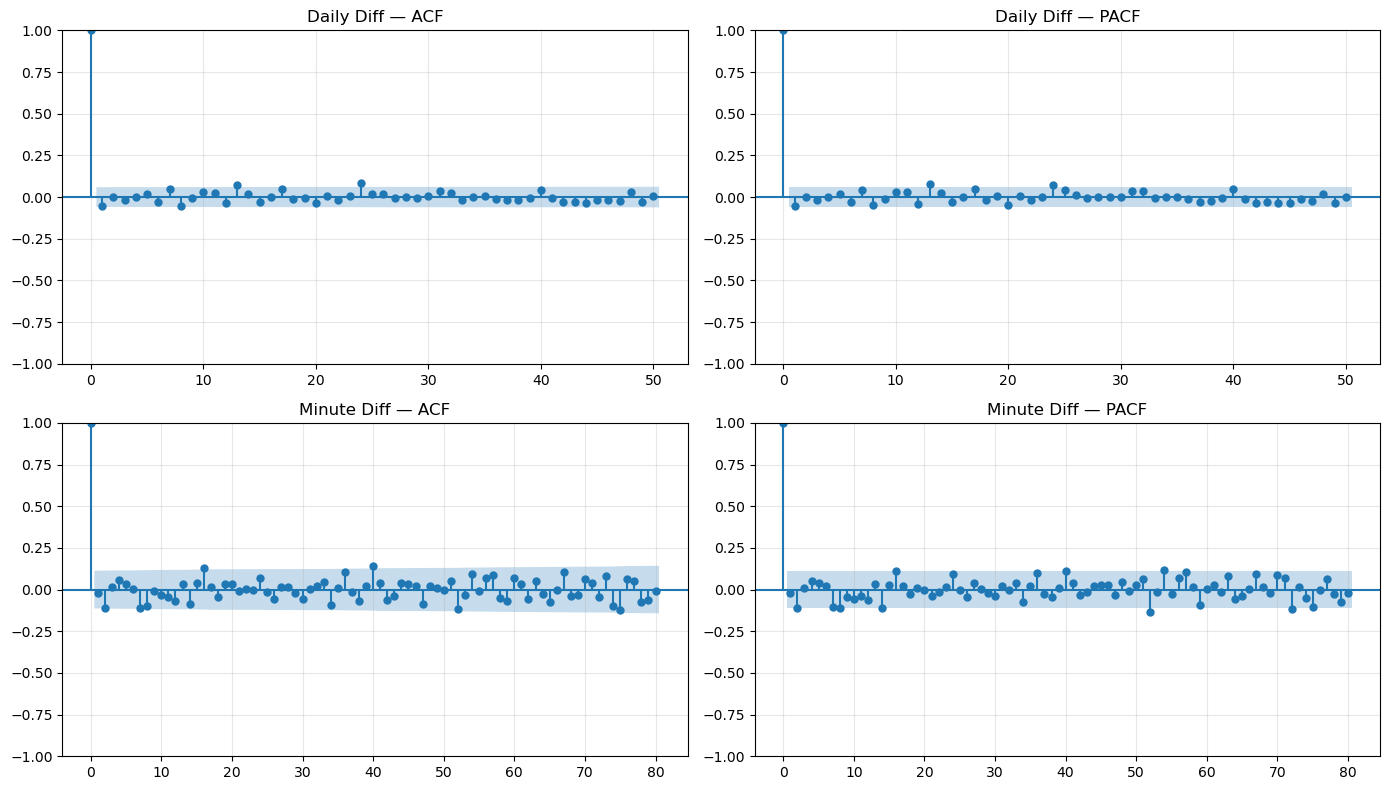


  Stationarity Tests — Daily Close — 1st Difference

  ADF Test:
    Statistic : -34.7812
    p-value   : 0.000000
    Crit  1%  : -3.4363
    Crit  5%  : -2.8642
    Crit 10%  : -2.5682
    → Stationary at 5% level

  KPSS Test:
    Statistic : 0.3229
    p-value   : 0.1000
    Crit  10% : 0.3470
    Crit   5% : 0.4630
    Crit 2.5% : 0.5740
    Crit   1% : 0.7390
    → Stationary at 5% level

  Stationarity Tests — Minute Close — 1st Difference

  ADF Test:
    Statistic : -13.7044
    p-value   : 0.000000
    Crit  1%  : -3.4526
    Crit  5%  : -2.8713
    Crit 10%  : -2.5720
    → Stationary at 5% level

  KPSS Test:
    Statistic : 0.2875
    p-value   : 0.1000
    Crit  10% : 0.3470
    Crit   5% : 0.4630
    Crit 2.5% : 0.5740
    Crit   1% : 0.7390
    → Stationary at 5% level


In [15]:
daily_diff  = daily["close"].diff().dropna()
minute_diff = minute["close"].diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(daily_diff,  lags=50, ax=axes[0, 0], title="Daily Diff — ACF")
plot_pacf(daily_diff, lags=50, ax=axes[0, 1], title="Daily Diff — PACF", method="ywm")
plot_acf(minute_diff,  lags=80, ax=axes[1, 0], title="Minute Diff — ACF")
plot_pacf(minute_diff, lags=80, ax=axes[1, 1], title="Minute Diff — PACF", method="ywm")
plt.tight_layout(); plt.show()

# Stationarity on differenced series
stationarity_tests(daily_diff,  "Daily Close — 1st Difference")
stationarity_tests(minute_diff, "Minute Close — 1st Difference")

### Log-Returns Analysis

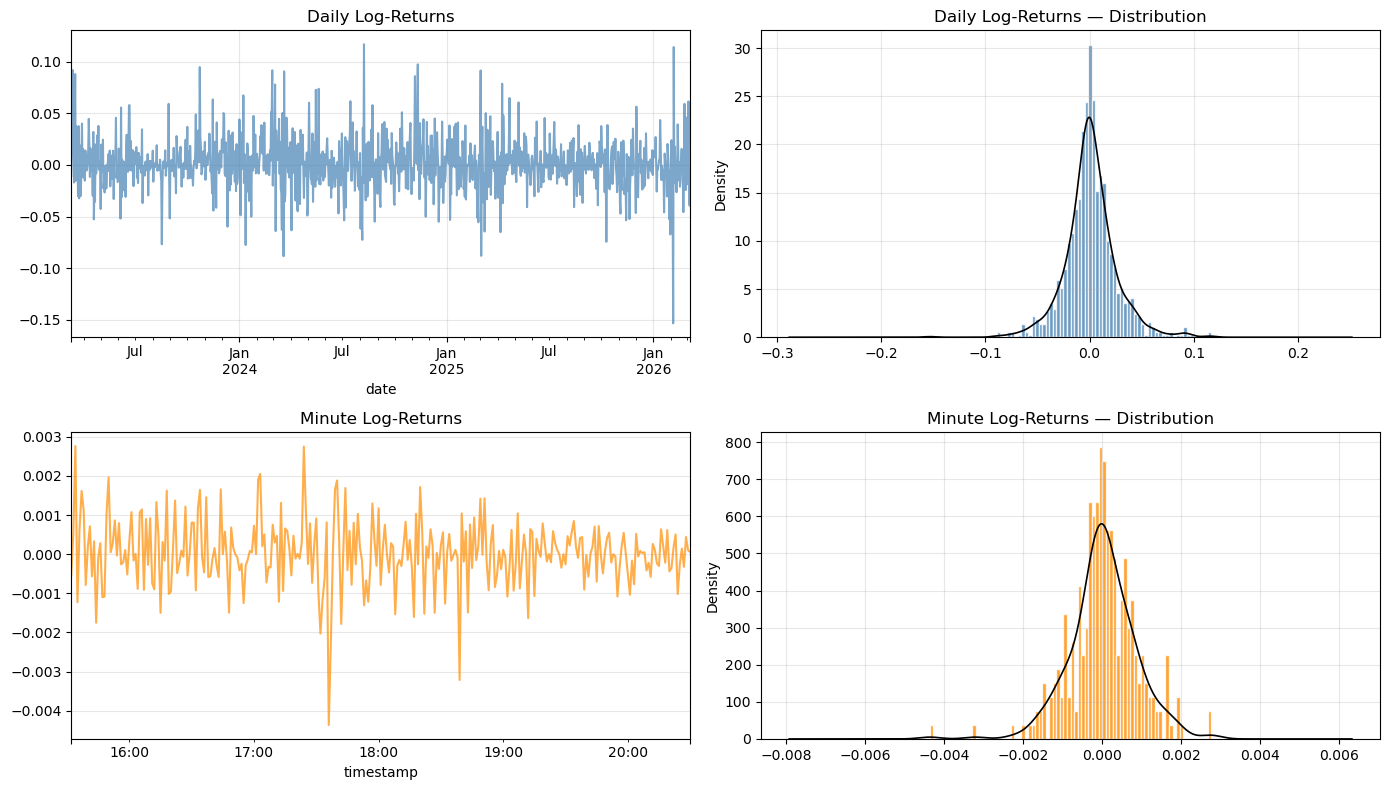


Daily log-returns — mean: 0.001093, std: 0.024720, skew: 0.1841, excess kurtosis: 3.6128

Minute log-returns — mean: 0.000027, std: 0.000845, skew: -0.4310, excess kurtosis: 3.0011


In [ ]:

daily["log_ret"]  = np.log(daily["close"] / daily["close"].shift(1))
minute["log_ret"] = np.log(minute["close"] / minute["close"].shift(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

daily["log_ret"].dropna().plot(ax=axes[0, 0], title="Daily Log-Returns", color="steelblue", alpha=0.7)
daily["log_ret"].dropna().plot.hist(bins=80, ax=axes[0, 1], density=True, color="steelblue", edgecolor="white", alpha=0.8)
daily["log_ret"].dropna().plot.kde(ax=axes[0, 1], color="black", linewidth=1.2)
axes[0, 1].set_title("Daily Log-Returns — Distribution")

minute["log_ret"].dropna().plot(ax=axes[1, 0], title="Minute Log-Returns", color="darkorange", alpha=0.7)
minute["log_ret"].dropna().plot.hist(bins=80, ax=axes[1, 1], density=True, color="darkorange", edgecolor="white", alpha=0.8)
minute["log_ret"].dropna().plot.kde(ax=axes[1, 1], color="black", linewidth=1.2)
axes[1, 1].set_title("Minute Log-Returns — Distribution")

plt.tight_layout(); plt.show()


for label, s in [("Daily", daily["log_ret"]), ("Minute", minute["log_ret"])]:
    s = s.dropna()
    from scipy.stats import skew, kurtosis
    print(f"\n{label} log-returns — mean: {s.mean():.6f}, std: {s.std():.6f}, "
          f"skew: {skew(s):.4f}, excess kurtosis: {kurtosis(s):.4f}")

### Rolling Volatility

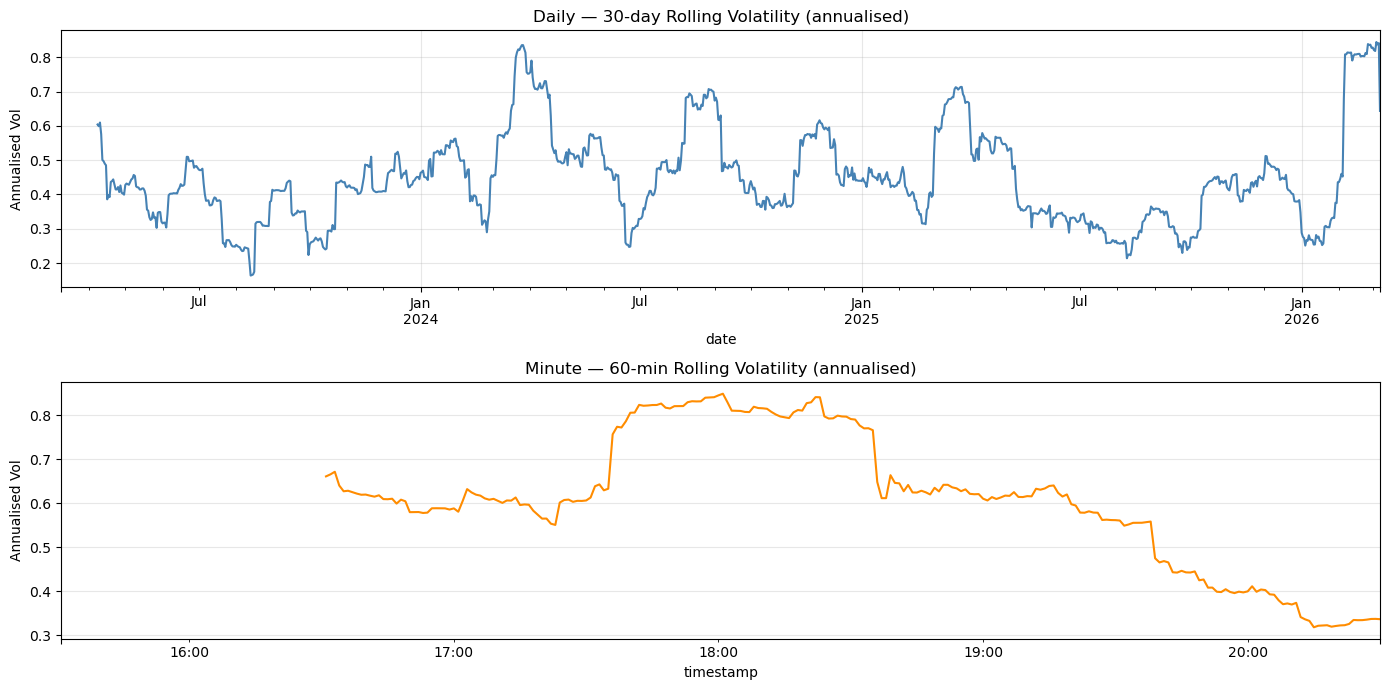

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# 30-day rolling volatility, annualised (×√365)
daily_vol = daily["log_ret"].rolling(30).std() * np.sqrt(365)
daily_vol.plot(ax=axes[0], title="Daily — 30-day Rolling Volatility (annualised)", color="steelblue")
axes[0].set_ylabel("Annualised Vol")

# 60-min rolling volatility, annualised (×√525600)
minute_vol = minute["log_ret"].rolling(60).std() * np.sqrt(525_600)
minute_vol.plot(ax=axes[1], title="Minute — 60-min Rolling Volatility (annualised)", color="darkorange")
axes[1].set_ylabel("Annualised Vol")

plt.tight_layout(); plt.show()

### Lag Scatter Plots
non-linear dependency via scatter of $x_t$ vs $x_{t-k}$.

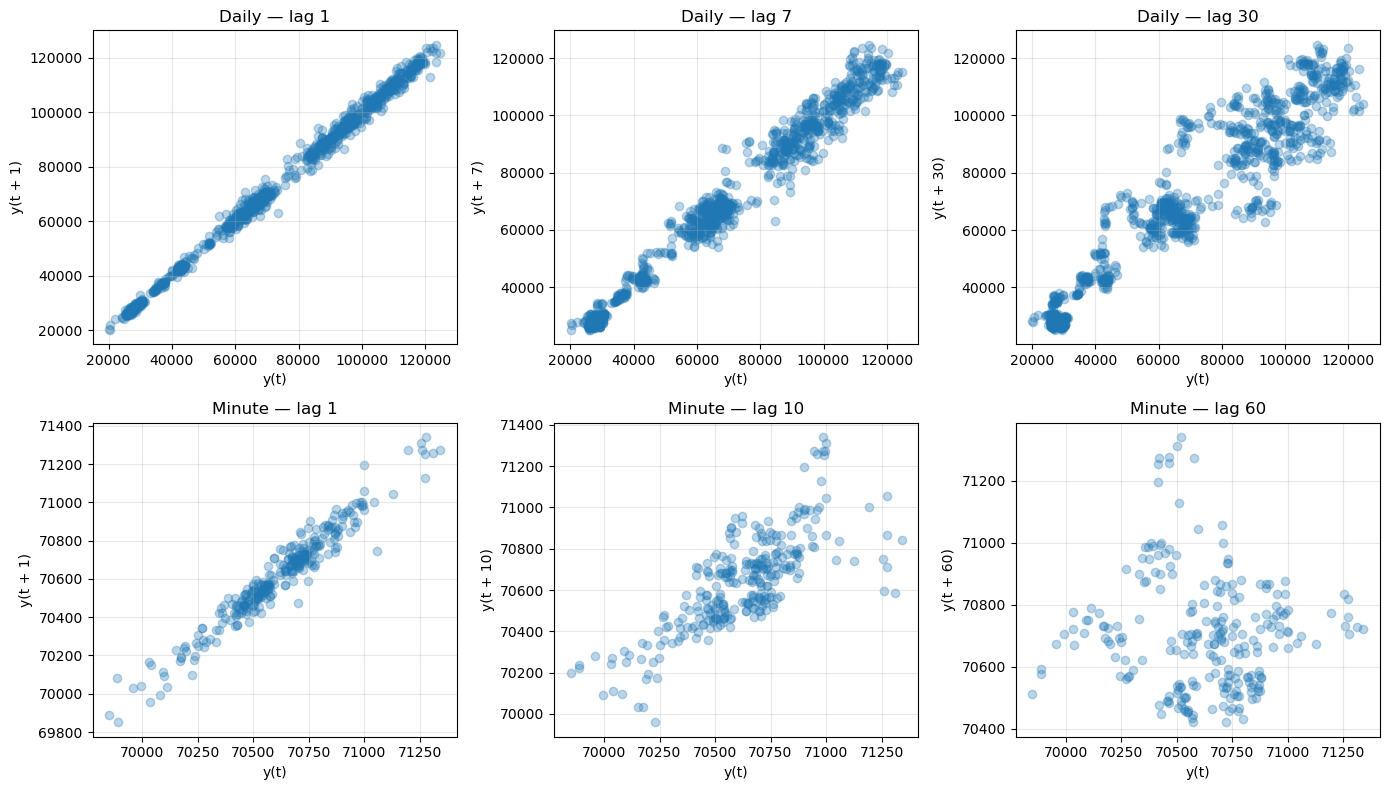

In [18]:
from pandas.plotting import lag_plot

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for j, lag in enumerate([1, 7, 30]):
    lag_plot(daily["close"], lag=lag, ax=axes[0, j], alpha=0.3)
    axes[0, j].set_title(f"Daily — lag {lag}")
for j, lag in enumerate([1, 10, 60]):
    lag_plot(minute["close"], lag=lag, ax=axes[1, j], alpha=0.3)
    axes[1, j].set_title(f"Minute — lag {lag}")
plt.tight_layout(); plt.show()

Volatility Clustering 

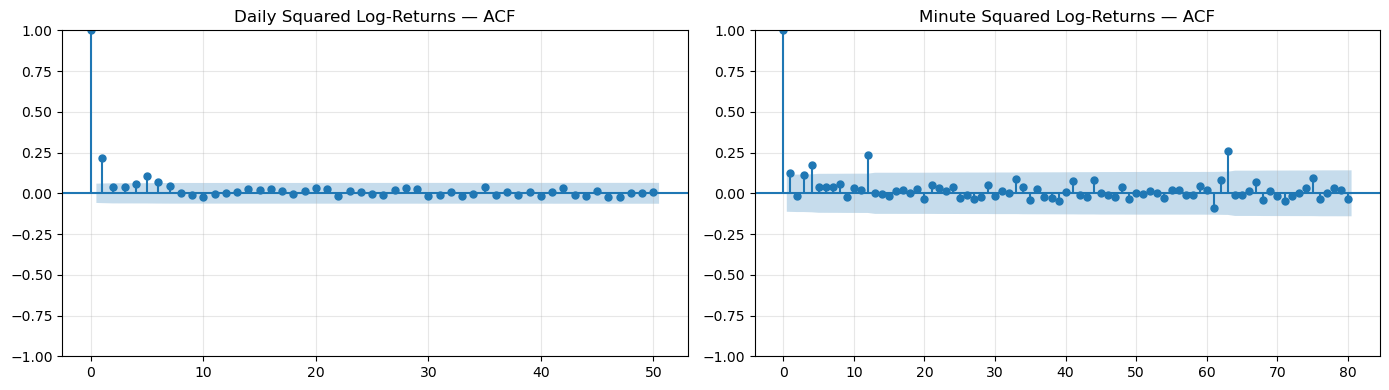

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily["log_ret"].dropna() ** 2,  lags=50, ax=axes[0], title="Daily Squared Log-Returns — ACF")
plot_acf(minute["log_ret"].dropna() ** 2, lags=80, ax=axes[1], title="Minute Squared Log-Returns — ACF")
plt.tight_layout(); plt.show()

QQ Plots

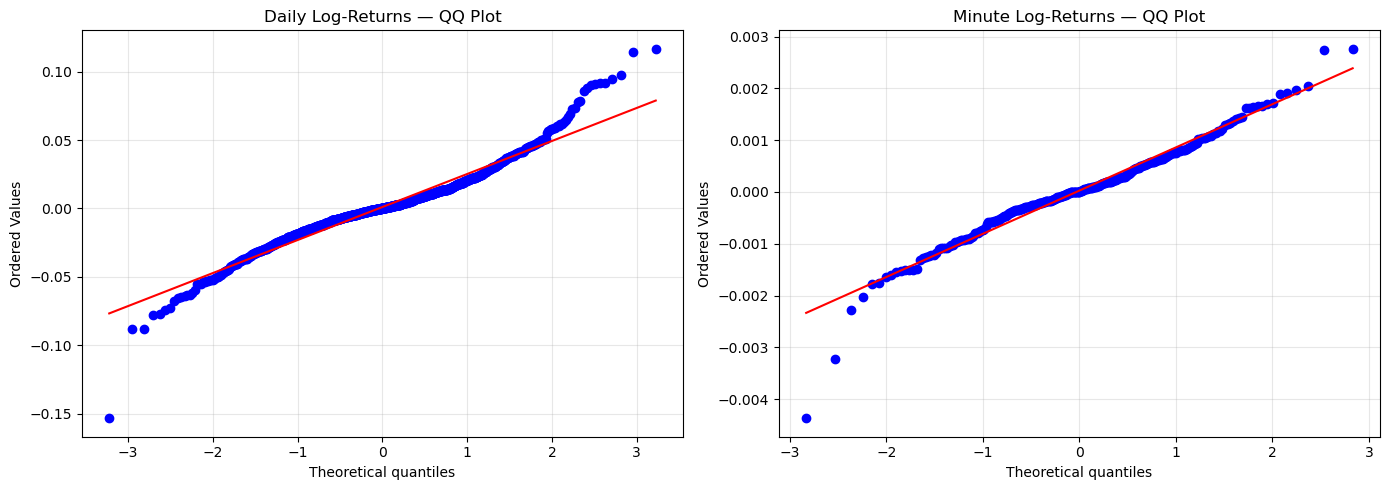

In [20]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stats.probplot(daily["log_ret"].dropna(), dist="norm", plot=axes[0])
axes[0].set_title("Daily Log-Returns — QQ Plot")
stats.probplot(minute["log_ret"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("Minute Log-Returns — QQ Plot")
plt.tight_layout(); plt.show()

Daily Close by Day-of-Week & Month

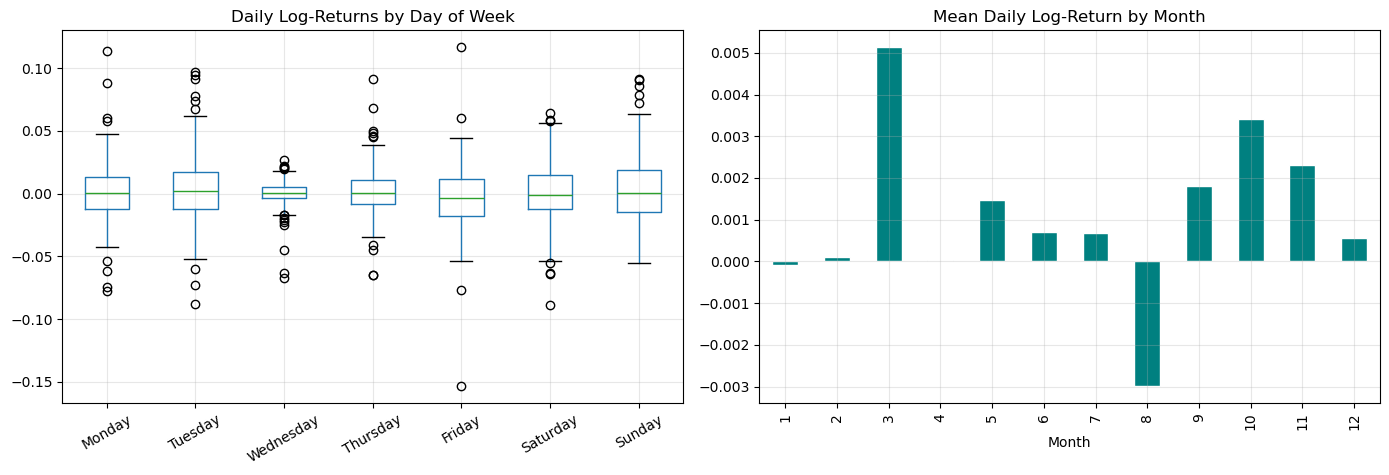

In [21]:
daily_tmp = daily.copy()
daily_tmp["dow"]   = daily_tmp.index.day_name()
daily_tmp["month"] = daily_tmp.index.month_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_tmp.boxplot(column="log_ret", by="dow", ax=axes[0], positions=range(7))
axes[0].set_xticklabels(dow_order, rotation=30)
axes[0].set_title("Daily Log-Returns by Day of Week")
axes[0].set_xlabel("")

month_means = daily_tmp.groupby(daily_tmp.index.month)["log_ret"].mean()
month_means.plot.bar(ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("Mean Daily Log-Return by Month")
axes[1].set_xlabel("Month")

plt.suptitle(""); plt.tight_layout(); plt.show()